<a href="https://colab.research.google.com/github/MauricioTurdo/Aprendizaje_Automatico/blob/main/Clase%204/Actividad_1_Regresion_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerías y carga de datos

In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (explained_variance_score,
    mean_absolute_error,mean_squared_error, r2_score,)

df = pd.read_csv('ventas-totales-nacionales-centros-compras-valores-mensuales.csv')
df.head()

,indice_tiempo,ventas_totales_precios_corrientes,ventas_gba_precios_corrientes,ventas_resto_precios_corrientes,ventas_totales_precios_constantes,ventas_gba_precios_constantes,ventas_resto_precios_constantes,ventas_totales_precios_constantes_original,ventas_totales_precios_constantes_desestacionalizada,ventas_totales_precios_constantes_tendencia_ciclo,...,indumentaria_calzado_marroquineria,ropa_accesorios_deportivos,amoblamientos_decoracion_textiles_hogar,patio_comidas,electronicos_electrodomesticos_computacion,jugueteria,libreria_papeleria,diversion_esparcimiento,perfumeria_farmacia,otros
0,2017-01-01,6366.880791,3898.707268,2468.173523,6344.563229,3898.717113,2445.846116,85.431183,94.814561,94.193042,...,2.257673e+09,514604833.0,256062858.0,1.000047e+09,1.160864e+09,89627070.0,106686034.0,366121606.0,215480713.0,399714261.0
1,2017-02-01,5886.706659,3586.495694,2300.210965,5843.476008,3580.982556,2262.493451,78.683914,93.848416,94.829837,...,2.130014e+09,562017187.0,231662194.0,9.955544e+08,8.189747e+08,59524171.0,101866339.0,415156976.0,199176194.0,372760408.0
2,2017-03-01,6635.467651,4151.904783,2483.562868,6430.963259,4024.997094,2405.966165,86.594582,94.666660,95.593484,...,2.630347e+09,723755643.0,244040589.0,9.596550e+08,9.206357e+08,63694075.0,117938183.0,350569687.0,223806121.0,401025226.0
3,2017-04-01,7644.785923,4766.023077,2878.762846,7161.302798,4450.829351,2710.473447,96.428793,99.189318,96.532052,...,3.228128e+09,757833375.0,270761604.0,1.044946e+09,1.039823e+09,67336483.0,96243142.0,488068353.0,215679821.0,435966504.0
4,2017-05-01,7244.804581,4534.990160,2709.814421,6714.174462,4206.383081,2507.791381,90.408094,96.385226,97.684620,...,3.093101e+09,715865481.0,265061717.0,9.718114e+08,1.071617e+09,68958633.0,84931265.0,331738540.0,221276490.0,420443580.0


# Analisis de Datos


In [35]:
print("Estructura y Tipos de Datos")
df.info()

print("Estadísticas Descriptivas (Numéricas)")
display(df.describe())

print("Valores Faltantes por Columna")
print(df.isna().sum())

print("Filas Duplicadas")
print(f"Cantidad de duplicados: {df.duplicated().sum()}")

Estructura y Tipos de Datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 21 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   indice_tiempo                                         115 non-null    object 
 1   ventas_totales_precios_corrientes                     115 non-null    float64
 2   ventas_gba_precios_corrientes                         115 non-null    float64
 3   ventas_resto_precios_corrientes                       115 non-null    float64
 4   ventas_totales_precios_constantes                     115 non-null    float64
 5   ventas_gba_precios_constantes                         115 non-null    float64
 6   ventas_resto_precios_constantes                       115 non-null    float64
 7   ventas_totales_precios_constantes_original            115 non-null    float64
 8   ventas_totales_precios_constante

,ventas_totales_precios_corrientes,ventas_gba_precios_corrientes,ventas_resto_precios_corrientes,ventas_totales_precios_constantes,ventas_gba_precios_constantes,ventas_resto_precios_constantes,ventas_totales_precios_constantes_original,ventas_totales_precios_constantes_desestacionalizada,ventas_totales_precios_constantes_tendencia_ciclo,total,indumentaria_calzado_marroquineria,ropa_accesorios_deportivos,amoblamientos_decoracion_textiles_hogar,patio_comidas,electronicos_electrodomesticos_computacion,jugueteria,libreria_papeleria,diversion_esparcimiento,perfumeria_farmacia,otros
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,1.150000e+02,1.150000e+02,1.150000e+02,1.150000e+02,1.150000e+02,1.150000e+02,1.150000e+02,1.150000e+02,1.080000e+02,1.150000e+02,1.150000e+02
mean,166366.356599,103159.701141,63206.655458,6138.255086,3740.475966,2397.779120,82.653191,82.925462,83.968680,1.663664e+11,6.309999e+10,2.224409e+10,7.793455e+09,2.682644e+10,1.787706e+10,1.786766e+09,2.078041e+09,6.894310e+09,8.033049e+09,1.015282e+10
std,227597.762444,141499.983580,86197.253486,1990.528812,1348.012815,654.970422,26.802985,22.478755,19.297127,2.275978e+11,8.592792e+10,3.133713e+10,1.099331e+10,3.834031e+10,2.345505e+10,2.883730e+09,2.912053e+09,1.034360e+10,1.165703e+10,1.372162e+10
min,360.682821,199.677181,161.005640,112.666171,63.421559,49.244612,1.517079,6.451327,17.564135,3.606828e+08,4.779847e+06,3.817530e+05,3.636887e+07,7.337164e+07,1.195824e+06,1.949440e+05,1.605326e+06,4.515852e+06,1.336710e+08,9.422983e+07
25%,9879.174171,6022.399704,4111.504973,5585.089452,3382.840533,2197.717414,75.204673,79.358794,82.242547,9.879174e+09,4.036567e+09,1.098247e+09,4.406294e+08,1.416120e+09,1.404761e+09,9.980541e+07,1.363457e+08,4.251325e+08,3.825374e+08,7.110123e+08
50%,31183.260665,18036.663802,12249.754206,6260.815754,3847.847076,2405.229748,84.303502,90.334269,89.924854,3.118326e+10,1.263487e+10,3.628543e+09,1.404499e+09,3.821810e+09,3.413949e+09,3.726050e+08,3.733805e+08,1.254968e+09,1.268777e+09,2.081882e+09
75%,292295.559803,185710.435614,106585.124189,7091.218280,4423.163328,2737.077899,95.485087,94.590329,94.115953,2.922956e+11,1.163272e+11,4.030518e+10,1.230692e+10,4.368346e+10,2.954055e+10,2.398635e+09,3.893975e+09,9.838915e+09,1.409016e+10,1.682861e+10
max,881262.589745,560302.408867,320960.180878,11471.942979,7322.225765,4149.717214,154.472677,109.014603,106.323601,8.812626e+11,3.876951e+11,1.166320e+11,3.926141e+10,1.475441e+11,7.165407e+10,1.699214e+10,1.328134e+10,5.547492e+10,4.991835e+10,5.134056e+10


Valores Faltantes por Columna
indice_tiempo                                           0
ventas_totales_precios_corrientes                       0
ventas_gba_precios_corrientes                           0
ventas_resto_precios_corrientes                         0
ventas_totales_precios_constantes                       0
ventas_gba_precios_constantes                           0
ventas_resto_precios_constantes                         0
ventas_totales_precios_constantes_original              0
ventas_totales_precios_constantes_desestacionalizada    0
ventas_totales_precios_constantes_tendencia_ciclo       0
total                                                   0
indumentaria_calzado_marroquineria                      0
ropa_accesorios_deportivos                              0
amoblamientos_decoracion_textiles_hogar                 0
patio_comidas                                           0
electronicos_electrodomesticos_computacion              0
jugueteria                                

El dataset "Ventas Totales Nacionales en Centros de Compras" publicado por el Ministerio de Economía de la Nación (INDEC) contiene 115 registros mensuales (desde enero de 2017 hasta julio de 2026) con 21 variables económicas y de consumo. El objetivo es analizar la evolución de las ventas y predecir el monto total de ventas a precios corrientes (ventas_totales_precios_corrientes), una variable numérica continua.

Registros duplicados: No se detectaron filas duplicadas

Valores faltantes: Únicamente la columna diversion_esparcimiento presenta 7 valores nulos


# Correlacion de Variables

In [36]:
df.corr(numeric_only=True)

,ventas_totales_precios_corrientes,ventas_gba_precios_corrientes,ventas_resto_precios_corrientes,ventas_totales_precios_constantes,ventas_gba_precios_constantes,ventas_resto_precios_constantes,ventas_totales_precios_constantes_original,ventas_totales_precios_constantes_desestacionalizada,ventas_totales_precios_constantes_tendencia_ciclo,total,indumentaria_calzado_marroquineria,ropa_accesorios_deportivos,amoblamientos_decoracion_textiles_hogar,patio_comidas,electronicos_electrodomesticos_computacion,jugueteria,libreria_papeleria,diversion_esparcimiento,perfumeria_farmacia,otros
ventas_totales_precios_corrientes,1.000000,0.999734,0.999283,0.262419,0.256267,0.270090,0.262419,0.219589,0.202968,1.000000,0.989927,0.993308,0.986771,0.982928,0.983325,0.900537,0.972189,0.900610,0.992312,0.994014
ventas_gba_precios_corrientes,0.999734,1.000000,0.998143,0.269472,0.263762,0.276101,0.269472,0.222171,0.205659,0.999734,0.992084,0.992356,0.985560,0.979814,0.981741,0.903934,0.971541,0.895483,0.992679,0.993442
ventas_resto_precios_corrientes,0.999283,0.998143,1.000000,0.250538,0.243668,0.259912,0.250538,0.215097,0.198316,0.999283,0.985243,0.993725,0.987619,0.986907,0.984790,0.893921,0.972130,0.907954,0.990564,0.993807
ventas_totales_precios_constantes,0.262419,0.269472,0.250538,1.000000,0.996989,0.987182,1.000000,0.827356,0.785064,0.262419,0.293826,0.247176,0.223641,0.215361,0.239348,0.313915,0.254254,0.147750,0.266418,0.251943
ventas_gba_precios_constantes,0.256267,0.263762,0.243668,0.996989,1.000000,0.971833,0.996989,0.836119,0.803036,0.256267,0.287718,0.240666,0.219035,0.209855,0.234069,0.306258,0.248635,0.134784,0.259615,0.246474
ventas_resto_precios_constantes,0.270090,0.276101,0.259912,0.987182,0.971833,1.000000,0.987182,0.793587,0.733148,0.270090,0.300810,0.255874,0.228869,0.222597,0.245662,0.323706,0.260984,0.171278,0.275352,0.258410
ventas_totales_precios_constantes_original,0.262419,0.269472,0.250538,1.000000,0.996989,0.987182,1.000000,0.827356,0.785064,0.262419,0.293826,0.247176,0.223641,0.215361,0.239348,0.313915,0.254254,0.147750,0.266418,0.251943
ventas_totales_precios_constantes_desestacionalizada,0.219589,0.222171,0.215097,0.827356,0.836119,0.793587,0.827356,1.000000,0.951800,0.219589,0.217379,0.211631,0.211426,0.213730,0.238797,0.181829,0.209468,0.121539,0.202373,0.219288
ventas_totales_precios_constantes_tendencia_ciclo,0.202968,0.205659,0.198316,0.785064,0.803036,0.733148,0.785064,0.951800,1.000000,0.202968,0.201807,0.194925,0.192444,0.198398,0.215764,0.172933,0.196267,0.103414,0.189685,0.202223
total,1.000000,0.999734,0.999283,0.262419,0.256267,0.270090,0.262419,0.219589,0.202968,1.000000,0.989927,0.993308,0.986771,0.982928,0.983325,0.900537,0.972189,0.900610,0.992312,0.994014


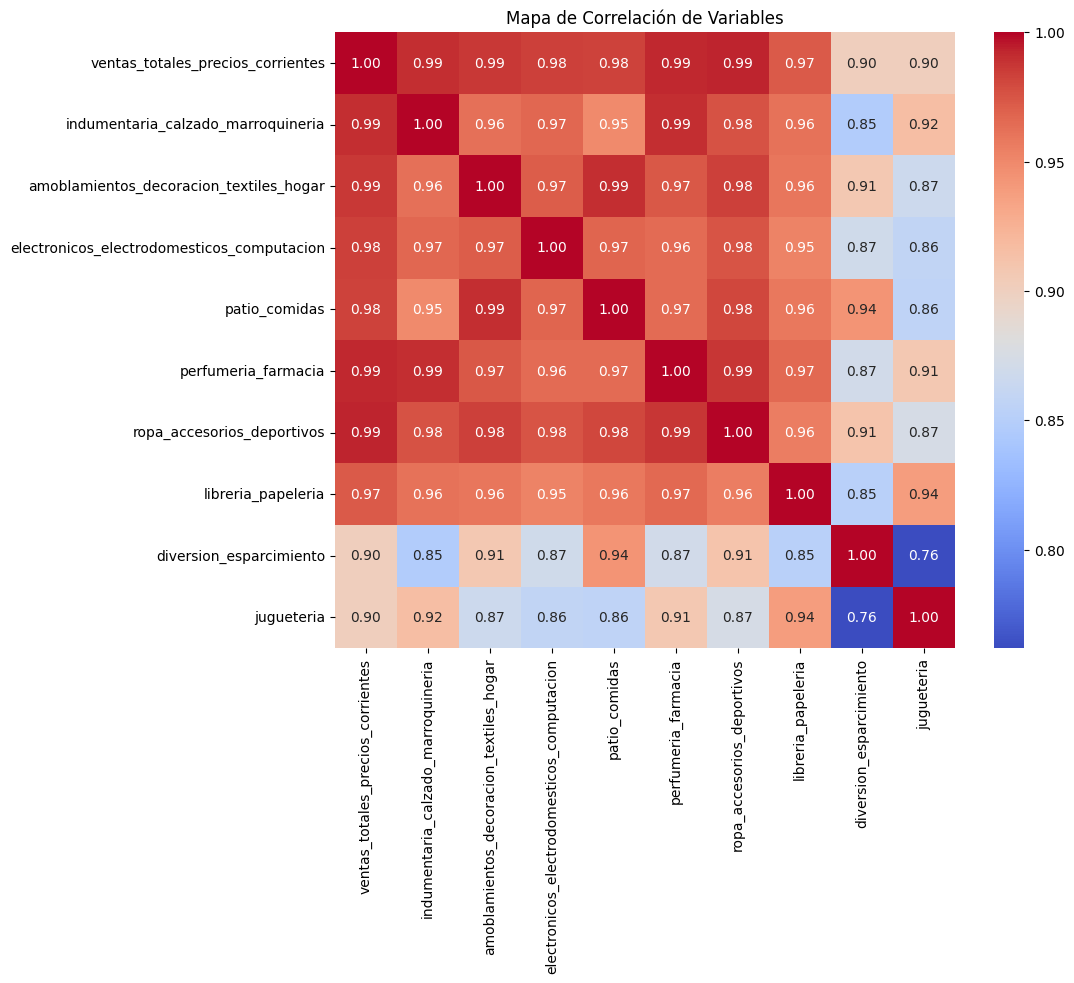

In [37]:
# 1. Seleccionar columnas de interés (rubros de ventas)
cols_rubros = [
    'ventas_totales_precios_corrientes',
    'indumentaria_calzado_marroquineria',
    'amoblamientos_decoracion_textiles_hogar',
    'electronicos_electrodomesticos_computacion',
    'patio_comidas',
    'perfumeria_farmacia',
    'ropa_accesorios_deportivos',
    'libreria_papeleria',
    'diversion_esparcimiento',
    'jugueteria',
]

# 2. Calcular matriz filtrando solo esas columnas
correlaciones = df[cols_rubros].corr(numeric_only=True)

# 3. Graficar mapa de calor
plt.figure(figsize=(10, 8))  # Ajusta el tamaño para que se lea mejor
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlación de Variables')
plt.show()



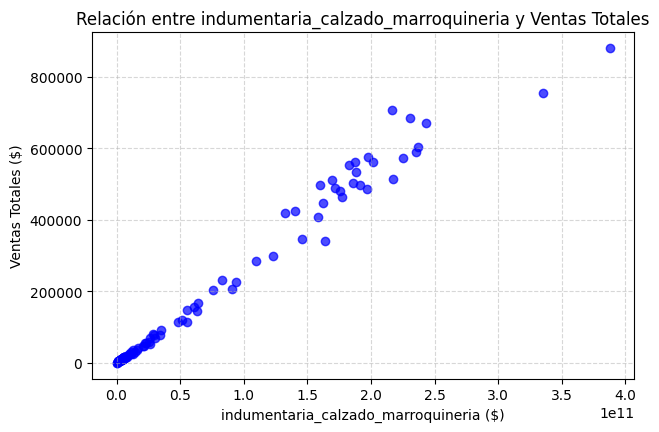

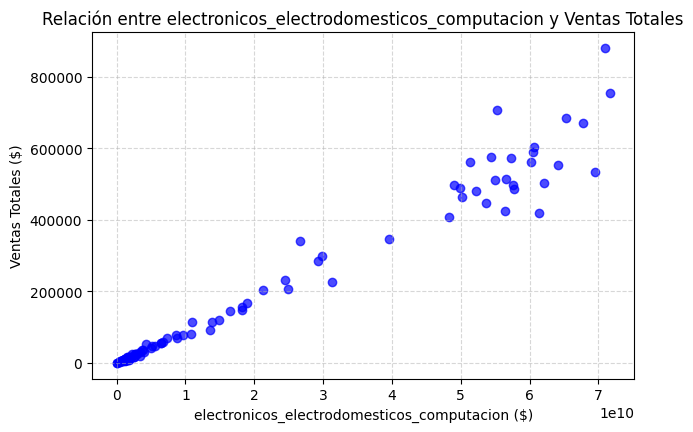

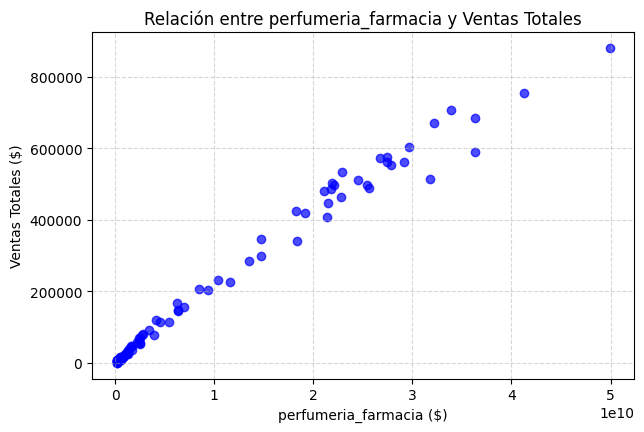

In [38]:
import matplotlib.pyplot as plt

# 1. Definir las 3 predictoras seleccionadas
predictoras = [
    'indumentaria_calzado_marroquineria',
    'electronicos_electrodomesticos_computacion',
    'perfumeria_farmacia',
]

# 2. Generar un gráfico de dispersión simple para cada predictora vs la variable objetivo
for var in predictoras:
  plt.figure(figsize=(7, 4.5))
  plt.scatter(
      df[var],
      df['ventas_totales_precios_corrientes'],
      color='blue',
      alpha=0.7,
  )

  plt.xlabel(f'{var} ($)')
  plt.ylabel('Ventas Totales ($)')
  plt.title(f'Relación entre {var} y Ventas Totales')
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

En el Mapa de correlaciones, se observa la fuerte relación que existe entre la Variable Objetivo (ventas_totales_precios_corrientes) y prácticamente todos los rubros principales que muestran una correlación lineal positiva extremadamente alta.

Los rubros con el impacto más alto son indumentaria_calzado_marroquineria (0.99), perfumeria_farmacia (0.99), ropa_accesorios_deportivos (0.99) y amoblamientos_decoracion_textiles_hogar (0.99).

Comportamiento Lineal Directo: En los tres gráficos se observa una clara alineación de los puntos en sentido ascendente de izquierda a derecha. Esto demuestra una relación lineal positiva, donde el incremento en la facturación de cada rubro en particular se traduce en un aumento proporcional de las ventas totales.

# Descripcion Estadistica

,Cantidad,Media,Desv. Est.,Mínimo,Mediana,Máximo
ventas_totales_precios_corrientes,115.0,1.663664e+05,2.275978e+05,3.606828e+02,3.118326e+04,8.812626e+05
indumentaria_calzado_marroquineria,115.0,6.309999e+10,8.592792e+10,4.779847e+06,1.263487e+10,3.876951e+11
electronicos_electrodomesticos_computacion,115.0,1.787706e+10,2.345505e+10,1.195824e+06,3.413949e+09,7.165407e+10
perfumeria_farmacia,115.0,8.033049e+09,1.165703e+10,1.336710e+08,1.268777e+09,4.991835e+10


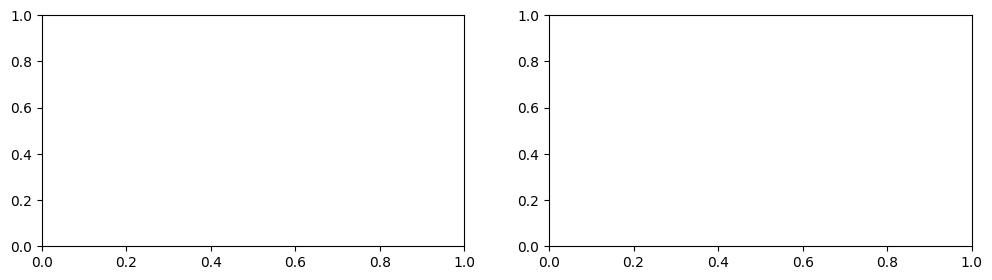

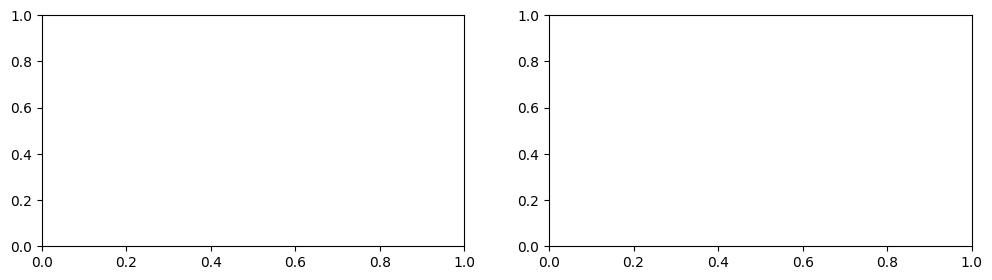

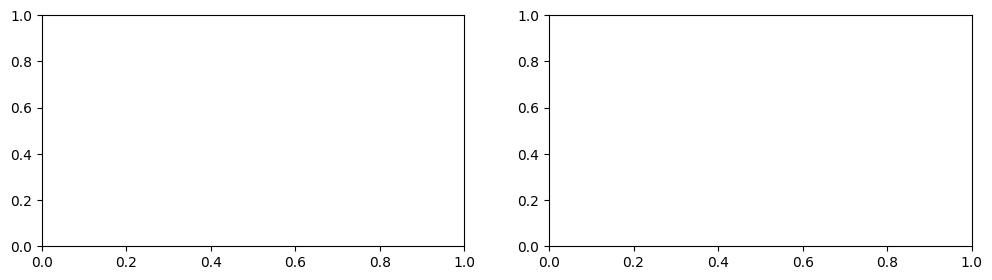

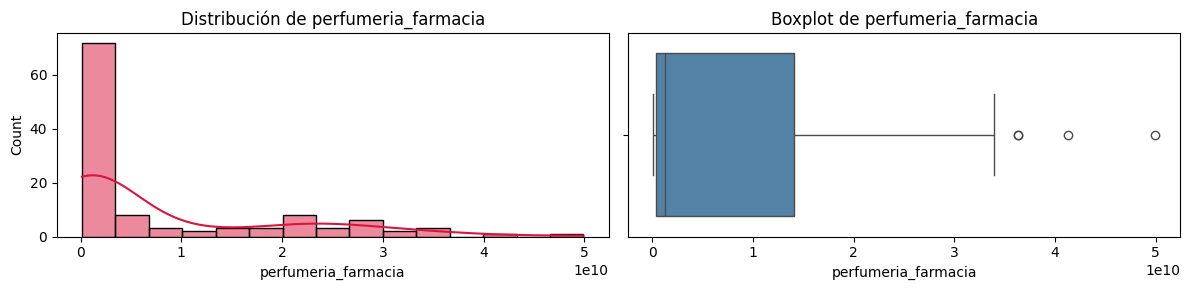

In [39]:
# 1. Definir lista EXCLUSIVA con la variable objetivo y las 4 predictoras
vars_seleccionadas = [
    'ventas_totales_precios_corrientes',
    'indumentaria_calzado_marroquineria',
    'electronicos_electrodomesticos_computacion',
    'perfumeria_farmacia',]

# 2. Filtrar DataFrame y mostrar Tabla de Estadística Descriptiva
tabla_desc = df[vars_seleccionadas].describe().T[
    ['count', 'mean', 'std', 'min', '50%', 'max']]
tabla_desc.columns = ['Cantidad','Media','Desv. Est.','Mínimo','Mediana',
    'Máximo',]
display(tabla_desc)

# 3. Generar Histograma y Boxplot ÚNICAMENTE para estas 5 variables
for col in vars_seleccionadas:
  fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Histograma
sns.histplot(
df[col].dropna(), kde=True, ax=axes[0], color='crimson', bins=15)
axes[0].set_title(f'Distribución de {col}')

# Boxplot
sns.boxplot(x=df[col].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

**Resumen del Análisis Estadístico Descriptivo**

Asimetría Positiva: En todas las variables evaluadas, la media supera a la mediana. Esto refleja un sesgo a la derecha impulsado por el aumento paulatino de los valores nominales.

Valores Extremos: Los puntos atípicos resaltados en los boxplots no corresponden a errores de carga, sino a picos estacionales de consumo histórico.




# Modelo de Regrecion Lineal

## Definicion de Variables

In [40]:
# 1. Definir la variable objetivo (y) y las variables explicativas (X)
target = 'ventas_totales_precios_corrientes'
features = ['indumentaria_calzado_marroquineria',
    'electronicos_electrodomesticos_computacion',
    'perfumeria_farmacia',]

X = df[features]
y = df[target]

# 2. Dividir en conjunto de entrenamiento (80%) y evaluación (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Muestras de entrenamiento (X_train): {X_train.shape[0]}')
print(f'Muestras de evaluación (X_test): {X_test.shape[0]}')


Muestras de entrenamiento (X_train): 92
Muestras de evaluación (X_test): 23


## Entrenar el Modelo y Calcular Métricas

In [41]:
# 1. Definir variables explicativas (X) y objetivo (y)
X = df[['indumentaria_calzado_marroquineria',
        'electronicos_electrodomesticos_computacion',
        'perfumeria_farmacia',]]
y = df['ventas_totales_precios_corrientes']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

# 4. Predicciones
y_pred_multiple = model_multiple.predict(X_test)

## Métricas, Coeficientes y Gráfico de Residuos

In [42]:
# 1. Impresión de Intercepto y Coeficientes
print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

# 2. Evaluación del modelo
print("\nEvaluación del modelo (Regresión Múltiple):")
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("MSE:", mean_squared_error(y_test, y_pred_multiple))
print("R²:", r2_score(y_test, y_pred_multiple))
print(
    "Varianza explicada:", explained_variance_score(y_test, y_pred_multiple)
)

Intercepto: 1937.1025423831597
Coeficientes: [3.12782133e-07 3.22589939e-06 1.09272797e-05]

Evaluación del modelo (Regresión Múltiple):
MAE: 8381.694181928846
MSE: 337700149.83153504
R²: 0.9937853854245593
Varianza explicada: 0.9940485059224407


MAE Indica que las predicciones se desvían, en promedio, solo 8.38 millones de pesos respecto a las ventas reales.

MSE Mide el promedio de los errores al cuadrado, penalizando las desviaciones más grandes causadas por los picos estacionales de ventas.

R² Indica qué tan bien el modelo explica la variabilidad de los datos (cercano a 1 = mejor). En este caso, explica el 99.38% de las ventas totales.

Varianza explicada: 0.9940 Confirma la alta precisión del modelo al capturar la tendencia general de los datos de prueba.

Intercepto ($1,937.10$): Es la base mínima de ventas estimada si estos tres rubros vendieran cero. Sirve como punto de partida de la fórmula.   

Coeficientes: Indican cuánto aumentan las ventas totales por cada peso que suma cada rubro[3.12782133e-07 3.22589939e-06 1.09272797e-05].

# Residuos

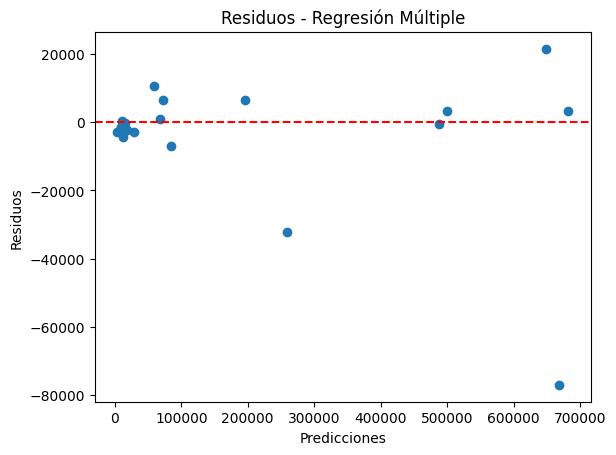

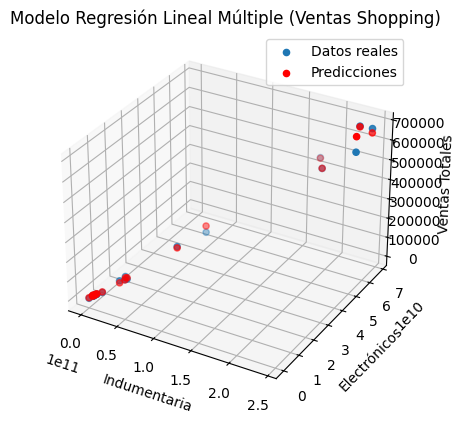

In [46]:
residuos = y_test - y_pred_multiple
plt.scatter(y_pred_multiple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test['indumentaria_calzado_marroquineria'],
           X_test['electronicos_electrodomesticos_computacion'],y_test,
           label='Datos reales',)
ax.scatter(X_test['indumentaria_calzado_marroquineria'],
           X_test['electronicos_electrodomesticos_computacion'],y_pred_multiple,
           color='red',label='Predicciones',)
ax.set_xlabel('Indumentaria')
ax.set_ylabel('Electrónicos')
ax.set_zlabel('Ventas Totales')
plt.title('Modelo Regresión Lineal Múltiple (Ventas Shopping)')
plt.legend()
plt.show()

Interpretación del Gráfico de Residuos:

El gráfico muestra los errores de predicción distribuidos de forma aleatoria alrededor de la línea cero. Esto confirma que el modelo de regresión lineal múltiple es adecuado, ya que los residuos no presentan un patrón o sesgo definido, validando la precisión general de las estimaciones.   

Interpretación del Gráfico 3D

Alineación de datos reales y predicciones: Los puntos rojos (predicciones del modelo) se superponen de manera casi exacta sobre los puntos azules (datos reales observados) en todo el espacio tridimensional.

Comportamiento lineal y escala: Se observa claramente cómo el crecimiento conjunto en las ventas de Indumentaria (eje X) y Electrónicos (eje Y) se traduce en un aumento proporcional directo de las Ventas Totales (eje Z).

Validación visual: La cercanía entre las esferas rojas y azules respalda de forma visual el elevado Coeficiente de Determinación obtenido (R2=0.9938), confirmando que el modelo ajusta con altísima precisión a lo largo de toda la serie de datos.


## Conclusión

El análisis demuestra que la combinación de los rubros de Indumentaria, Electrónica y Perfumería constituye un conjunto de predictores sumamente eficiente para estimar la facturación total en centros comerciales.
El modelo de Regresión Lineal Múltiple resulta técnicamente robusto, consistente y de alta precisión para el conjunto de datos evaluado, sustentado por los siguientes valores determinantes:

Poder Explicativo Excepcional (R2 = 0.9938 / Varianza Explicada = 0.9940): El modelo logra capturar y explicar el 99.38% de la variabilidad de las ventas totales reales en el conjunto de prueba.

Margen de Error Mínimo (text{MAE} = 8,381.69): La desviación promedio entre los valores reales y predichos es de solo $8.38 millones de pesos, un margen insignificante frente al volumen global de facturación.   

Impacto por Rubro: Con un intercepto base de 1,937.10, el coeficiente de Perfumería y Farmacia (1.09 x 10^-5) se consolidó como la variable de mayor peso relativo en las estimaciones, seguida por Electrónicos (3.23 x 10^-6) e Indumentaria (3.13 x 10^-7).   